In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
# plot settings
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'lines.linewidth': 1.2,
    'lines.markersize': 4,
    'legend.fontsize': 9,
    'legend.frameon': True,
    'legend.loc': 'best',
    'axes.grid': False,
    'grid.alpha': 0.3,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.transparent': True,
    'text.usetex': False,
    'mathtext.default': 'regular'
})
width = 17.5 / 2.54
width = 17.5 / 2.54

In [4]:
# load raw dataset
major_dataset = pd.read_excel('Major Garnet Dataset.xlsx')
major_dataset['Type'].value_counts()

Type
Metamorphic    2090
Igneous        2002
Peritectic     1304
Name: count, dtype: int64

In [5]:
features = major_dataset.columns[1:-1]
feature_names = ['SiO$_2$', 'TiO$_2$', 'Al$_2$O$_3$', 'Cr$_2$O$_3$', 'FeO$_T$', 'MnO', 'MgO', 'CaO']
# fill missing values
major_dataset.fillna(0.001, inplace=True)
# filter dataset
major_dataset = major_dataset.query('97.50 < Sum < 102.50')

In [6]:
major_dataset['Type'].value_counts()

Type
Metamorphic    2054
Igneous        1961
Peritectic     1281
Name: count, dtype: int64

In [7]:
major_dataset.drop(columns=['sample'], inplace=True)

In [8]:
X = major_dataset.iloc[:, 1:-1]
y = major_dataset['Type']

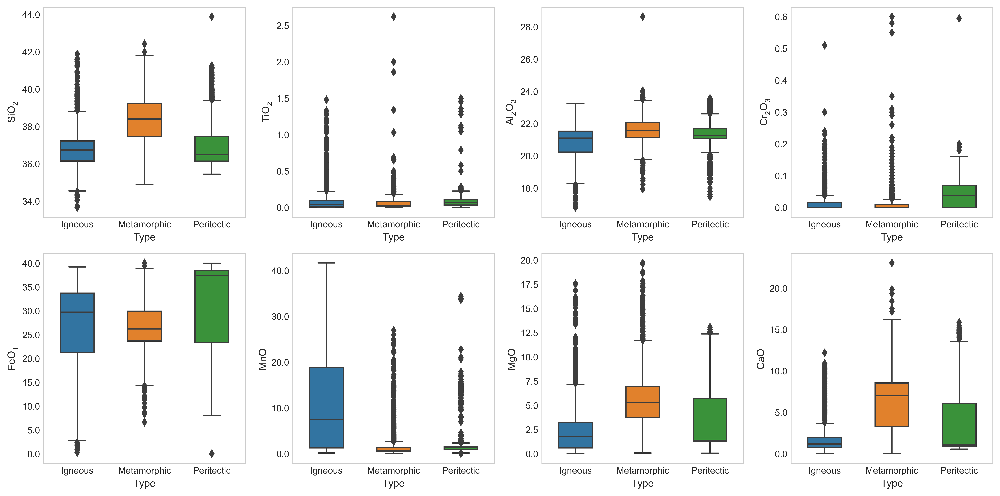

In [9]:
# Major Element Data
import matplotlib.ticker as ticker
fig, axes = plt.subplots(2, 4, figsize=[width*2, width], dpi=600)
for i in range(8):
    ax = axes[i//4, i-(i//4)*4]
    sns.boxplot(y=major_dataset.columns[i+1], x='Type', data=major_dataset, ax=ax, width=0.5)
    ax.set_ylabel(feature_names[i])
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.tight_layout()
# plt.savefig('Major Elements Distribution.svg')
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=10, shuffle=True)

from sklearn.preprocessing import StandardScaler
# Standardization
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [28]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
# RandomizedSearchCV + Cross Validation
parameters = {'max_features':range(1, 9), 'n_estimators':range(25, 525, 25), 'max_depth':range(1, 9), 'min_samples_split':range(5,25,5), 'min_samples_leaf':range(2,12,2)}
grid1 = RandomizedSearchCV(estimator=rf, param_distributions=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10), n_iter=200, scoring='f1_macro', random_state=10)
grid1.fit(X_train_scaled, y_train)
print('Results of 200 training rounds for the Random Forest Model: \n',grid1.cv_results_['mean_test_score'])
print('Optimal Random Forest Model Parameters: \n',grid1.best_params_)
print('Optimal Random Forest Model F1_score (Training): ', grid1.best_score_)
print('Optimal Random Forest Model F1_score (Test): ',grid1.best_estimator_.score(X_test_scaled, y_test))

Results of 30 training rounds for the Random Forest Model: 
 [0.88184218 0.78142199 0.88350158 0.78235456 0.80146919 0.81780272
 0.73681983 0.87845936 0.80864568 0.85206791 0.81160688 0.80205035
 0.80276998 0.88916218 0.8297736  0.8538892  0.86002832 0.74159583
 0.90362828 0.88077461 0.88553843 0.61780814 0.75313516 0.78061231
 0.74877554 0.91921265 0.90288118 0.86277149 0.85809846 0.83116196
 0.85488857 0.83061825 0.77339603 0.87231728 0.88372939 0.8827146
 0.76011323 0.73053301 0.79021014 0.56862285 0.7822448  0.61776495
 0.8793703  0.79434674 0.82919617 0.77200253 0.61429981 0.82805586
 0.89994743 0.8579412  0.85608609 0.78214431 0.89393959 0.89558283
 0.83117868 0.88624907 0.73588658 0.89642396 0.63008224 0.75202679
 0.91070685 0.90946806 0.77204908 0.87876236 0.85268011 0.86247228
 0.88180834 0.56875163 0.88751276 0.78112162 0.74124079 0.81161279
 0.79593752 0.78229824 0.83140473 0.87749    0.85981226 0.85654055
 0.88282379 0.87177404 0.81320085 0.73363957 0.88126299 0.77030892
 0

In [33]:
# Adaboost Model
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier())
# RandomizedSearchCV + Cross Validation
parameters = {'n_estimators': range(25, 525, 25),'learning_rate':scipy.stats.uniform(0.01, 0.20)}
grid2 = RandomizedSearchCV(estimator=ada, param_distributions=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10), n_iter=200, scoring='f1_macro', random_state=10)
grid2.fit(X_train_scaled, y_train)
print('Results of 200 training rounds for the Adaboost Model: \n',grid2.cv_results_['mean_test_score'])
print('Optimal Adaboost Model Parameters: \n',grid2.best_params_)
print('Optimal Adaboost Model F1_score (Training): ', grid2.best_score_)
print('Optimal Adaboost Model F1_score (Test): ',grid2.best_estimator_.score(X_test_scaled, y_test))

Results of 30 training rounds for the Adaboost Model: 
 [0.89512828 0.89349367 0.89568722 0.90073527 0.8950514  0.89991601
 0.89638519 0.90001389 0.8970313  0.89391435 0.89446798 0.89669819
 0.89576202 0.89444748 0.89979714 0.89737899 0.89436745 0.89429385
 0.89723602 0.89458635 0.89468435 0.89765657 0.89798216 0.89939484
 0.89313079 0.89848643 0.89289673 0.89923899 0.89769837 0.89507715
 0.89877175 0.8951237  0.89531072 0.89838795 0.89377623 0.89461968
 0.89720858 0.89450259 0.89612868 0.89257893 0.89599041 0.89468063
 0.8955594  0.90049299 0.89555417 0.89396887 0.89391135 0.8989081
 0.89522143 0.90510202 0.89952716 0.89523474 0.8974081  0.89597203
 0.89428525 0.89813893 0.89525494 0.89385817 0.89421114 0.89559898
 0.89412985 0.89518284 0.89589803 0.89472119 0.89462193 0.90012438
 0.89795624 0.89773952 0.89442635 0.8942046  0.89492002 0.89535805
 0.89565818 0.89514504 0.90032205 0.89335858 0.89768362 0.90000881
 0.89496139 0.89440334 0.89424675 0.89683674 0.89655998 0.89450492
 0.8951

In [31]:
# XGBoost Model
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

from xgboost import XGBClassifier
xgb = XGBClassifier()
# RandomizedSearchCV + Cross Validation
parameters = {'n_estimators':range(25, 525, 25), 'max_depth':range(1, 9), 'learning_rate':scipy.stats.uniform(0.01, 0.20), 'reg_alpha': scipy.stats.uniform(0, 1), 'reg_lambda': scipy.stats.uniform(0.5, 2.5)}
grid3 = RandomizedSearchCV(estimator=xgb, param_distributions=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10), n_iter=200, scoring='f1_macro', random_state=10)
grid3.fit(X_train_scaled, y_train_encoded)
print('Results of 200 training rounds for the XGBoost Model: \n',grid3.cv_results_['mean_test_score'])
print('Optimal XGBoost Model Parameters: \n',grid3.best_params_)
print('Optimal XGBoost Model F1_score (Training): ', grid3.best_score_)
print('Optimal XGBoost Model F1_score (Test): ',grid3.best_estimator_.score(X_test_scaled, y_test_encoded))

Results of 30 training rounds for the XGBoost Model: 
 [0.93740396 0.86477486 0.93262579 0.84241291 0.92023658 0.93314836
 0.9067053  0.9354926  0.77035797 0.91745329 0.93451099 0.87168203
 0.93440128 0.93431543 0.88769651 0.76989242 0.84255804 0.91182256
 0.81585357 0.93762631 0.93177798 0.90858521 0.92779224 0.93405134
 0.82115737 0.93572969 0.93521061 0.93557157 0.93505067 0.79450036
 0.93647008 0.93652904 0.934463   0.91555457 0.85359172 0.80098578
 0.92947989 0.93507448 0.93181489 0.9332435  0.93404094 0.93664475
 0.93457082 0.83284952 0.91904645 0.91491845 0.92357091 0.90286998
 0.93782658 0.93492274 0.93666439 0.80268872 0.93315369 0.82972532
 0.86123929 0.80604731 0.91157033 0.93103806 0.78467599 0.92552607
 0.93481226 0.93459771 0.93505286 0.93476103 0.91990375 0.90659586
 0.93358789 0.92700269 0.92392381 0.93491011 0.92992923 0.89141214
 0.92284698 0.93400824 0.91956268 0.93804925 0.91729661 0.93465014
 0.86802005 0.92080396 0.93061738 0.93486893 0.93512075 0.93494968
 0.9067

In [32]:
# SVM Model
from sklearn.svm import SVC
svc = SVC()
# RandomizedSearchCV + Cross Validation
parameters = {'C':np.arange(0.001, 10.001, 0.05), 'kernel':['linear', 'poly', 'rbf', 'sigmoid']}
grid4 = RandomizedSearchCV(estimator=svc, param_distributions=parameters, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=10), n_iter=200, scoring='f1_macro', random_state=10)
grid4.fit(X_train_scaled, y_train)
print('Results of 200 training rounds for the SVM Model: \n',grid4.cv_results_['mean_test_score'])
print('Optimal SVM Model Parameters: \n',grid4.best_params_)
print('Optimal SVM Model F1_score (Training): ', grid4.best_score_)
print('Optimal SVM Model F1_score (Test): ',grid4.best_estimator_.score(X_test_scaled, y_test))

Results of 30 training rounds for the SVM Model: 
 [0.60153474 0.8794529  0.89192167 0.72975539 0.49542443 0.87958073
 0.86486747 0.51105401 0.50980697 0.49997483 0.72972894 0.7292755
 0.73080925 0.50405906 0.52027419 0.83532415 0.73003501 0.73003501
 0.50012515 0.87552104 0.83531976 0.49577585 0.57184942 0.82950745
 0.86943116 0.72923322 0.72975539 0.73023118 0.82868972 0.49634654
 0.73009979 0.87409713 0.83233249 0.88855496 0.50442663 0.73003501
 0.7288922  0.82596552 0.80624513 0.86920432 0.83253476 0.49577585
 0.73003501 0.83624988 0.87020158 0.73075625 0.72995151 0.83213278
 0.49924707 0.82605823 0.83506071 0.7296563  0.83624988 0.4979445
 0.72960215 0.73003501 0.72995151 0.50473977 0.7292755  0.82223804
 0.82605951 0.83048501 0.83204263 0.5012092  0.72998998 0.72865777
 0.81908597 0.72923322 0.49800998 0.51086887 0.73006452 0.73018616
 0.83567575 0.72864741 0.49698422 0.82842572 0.50404528 0.73023118
 0.49502783 0.52450983 0.7308389  0.72923322 0.82810409 0.73010129
 0.73023118 0

In [34]:
models = [grid1.best_estimator_, grid2.best_estimator_, grid3.best_estimator_, grid4.best_estimator_]
names = ['Random Forest', 'AdaBoost', 'XGBoost', 'SVM']

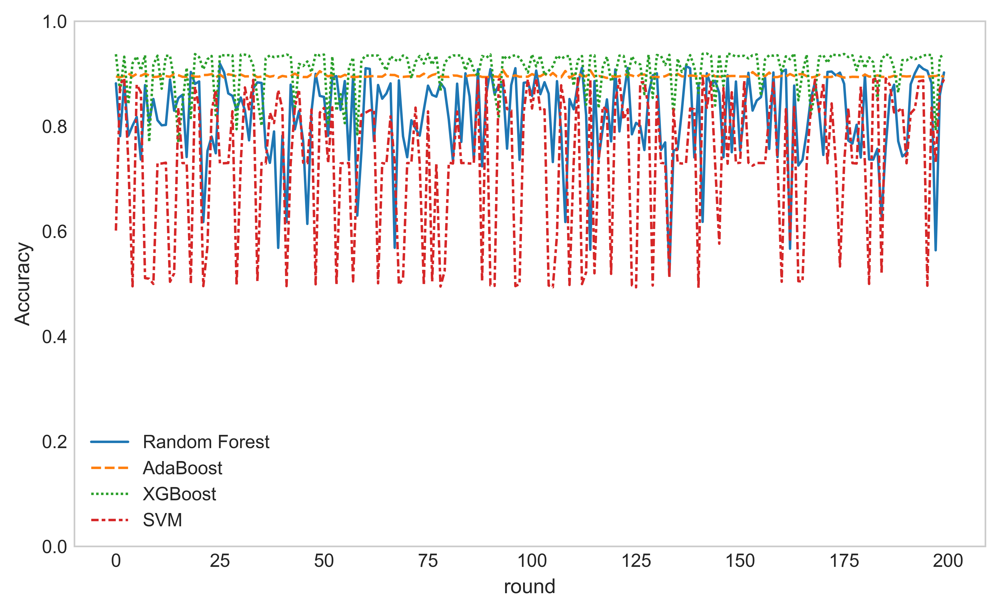

In [35]:
# Hyperparameter Tuning Results
Accuracy_df = pd.DataFrame({'Random Forest': grid1.cv_results_['mean_test_score'], 'AdaBoost': grid2.cv_results_['mean_test_score'], 
                            'XGBoost': grid3.cv_results_['mean_test_score'], 'SVM': grid4.cv_results_['mean_test_score']})

plt.figure(figsize=[width, width*0.618], dpi=900)

sns.lineplot(data=Accuracy_df)
plt.xlabel('round')
plt.ylabel('F1_score')
plt.ylim([0,1])
plt.legend(frameon=False)
plt.tight_layout()
# plt.savefig('Major_accuracy_line_results.svg', bbox_inches='tight')
plt.show()

In [36]:
for i in range(4):
    print('%s Min F1_score: %f'%(names[i], Accuracy_df[names[i]].min()))
    print('%s Max F1_score: %f'%(names[i], Accuracy_df[names[i]].max()))
    print('%s Mean F1_score: %f\n'%(names[i], Accuracy_df[names[i]].mean()))        

Random Forest Min: 0.516998
Random Forest Max: 0.919213
Random Forest Mean: 0.819490

AdaBoost Min: 0.892095
AdaBoost Max: 0.907145
AdaBoost Mean: 0.896138

XGBoost Min: 0.769892
XGBoost Max: 0.938900
XGBoost Mean: 0.910740

SVM Min: 0.492442
SVM Max: 0.892074
SVM Mean: 0.731632



In [19]:
# Confusion Matrix of Prediction
from sklearn.metrics import precision_score, f1_score, recall_score, confusion_matrix
def Confusion_Matrix_Plot(model, X, y, ax):
    try:
        sns.heatmap(confusion_matrix(y, model.predict(X)), annot=True, linewidths=0.6, cmap='Blues', cbar=False, fmt='d', square=True, annot_kws={'size':6}, ax=ax)
    except:
        sns.heatmap(confusion_matrix(y, le.inverse_transform(model.predict(X))), annot=True, linewidths=0.6, cmap='Blues', cbar=False, fmt='d', square=True, annot_kws={'size':6}, ax=ax)
    ax.set_xticks([i+0.5 for i in range(3)], label_names, size=8)
    ax.set_yticks([i+0.5 for i in range(3)], label_names, size=8, rotation=0)

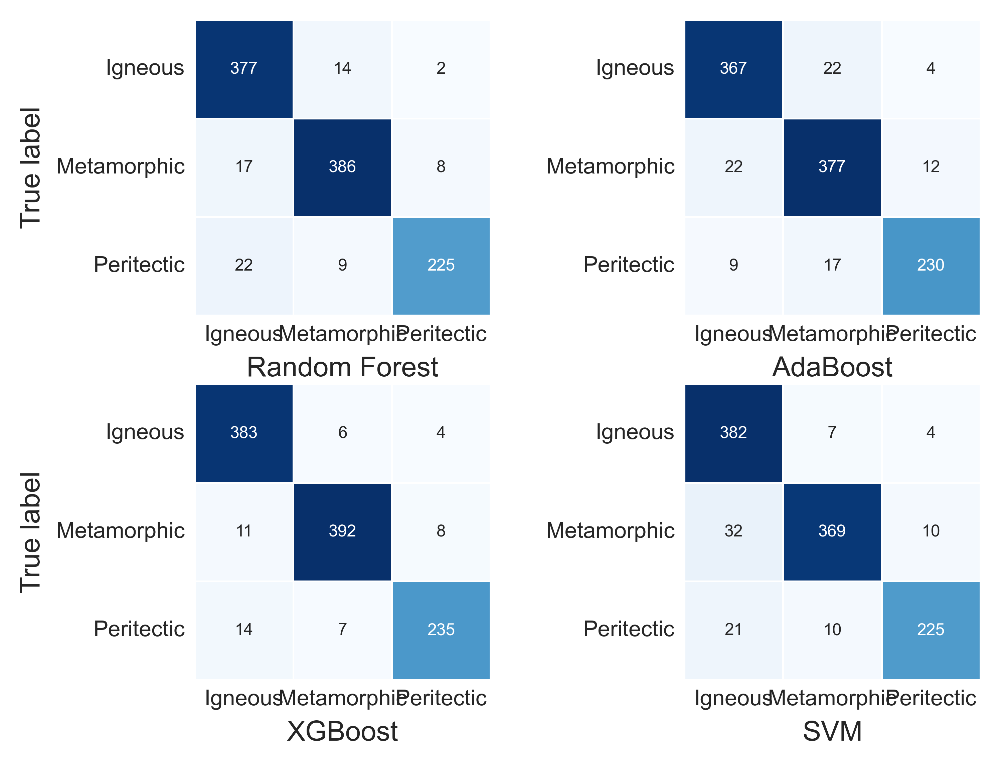

In [37]:
label_names = grid1.classes_
fig, axes = plt.subplots(2, 2, dpi=600)
for i in range(4):
    ax = axes[i//2, i-(i//2)*2]
    Confusion_Matrix_Plot(models[i], X_test_scaled, y_test, ax)
    ax.set_xlabel(names[i])
axes[0,0].set_ylabel('True label')
axes[1,0].set_ylabel('True label')
plt.tight_layout(h_pad=0.1)
# plt.savefig('Major_Feature_importance_ConfusionMatrix.svg', bbox_inches='tight')
plt.show()

In [21]:
# PCA Analysis
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
PCA_df = pd.DataFrame(pca.fit_transform(scaler.fit_transform(X)),columns=['PCA1','PCA2'])
PCA_df['Type'] = y

PCA_output = ['', '']
for i in range(2):
    for j in range(8):
        if pca.components_[i][j] > 0:
            PCA_output[i] += '+ '+'{:.2f}'.format(pca.components_[i][j])+'*'+feature_names[j]+' '
        else:
            PCA_output[i] += ' '+'{:.2f}'.format(pca.components_[i][j])+'*'+feature_names[j]+' '
    PCA_output[i] = PCA_output[i][1:]
print('PCA1 = ', PCA_output[0])
print('PCA2 = ', PCA_output[1])

PCA1 =   0.51*SiO$_2$ + 0.03*TiO$_2$ + 0.43*Al$_2$O$_3$ + 0.07*Cr$_2$O$_3$  -0.11*FeO$_T$  -0.39*MnO + 0.53*MgO + 0.32*CaO 
PCA2 =   0.19*SiO$_2$ + 0.24*TiO$_2$  -0.29*Al$_2$O$_3$  -0.23*Cr$_2$O$_3$  -0.65*FeO$_T$ + 0.43*MnO + 0.02*MgO + 0.40*CaO 


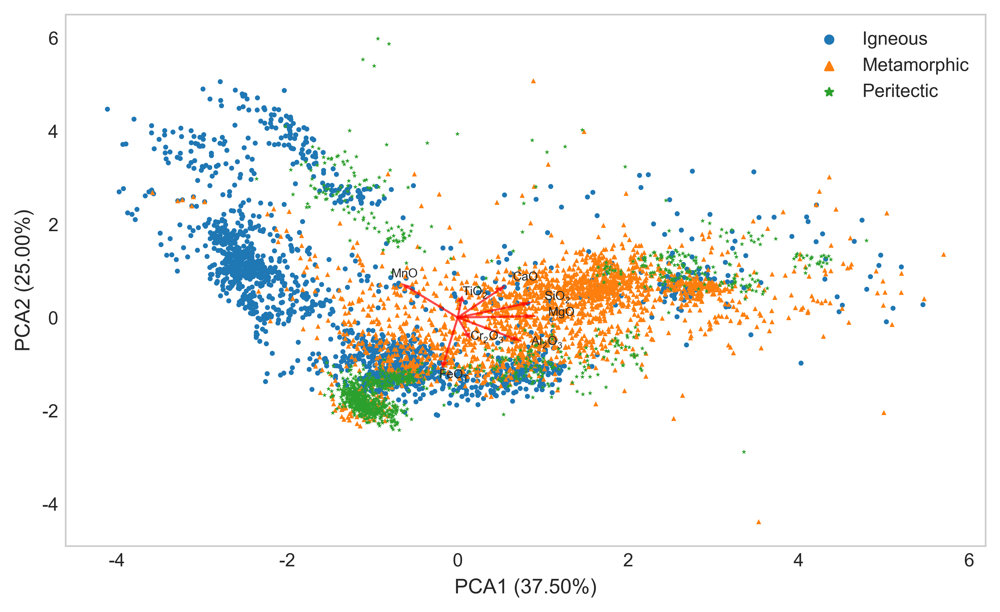

In [22]:
plt.figure(figsize=(width, width*0.618))
    
# plot points
marker_dict = {'Igneous': 'o', 'Peritectic': '*', 'Metamorphic': '^'}
# plt.figure(figsize=(width, width*0.618), dpi=900)
sns.scatterplot(x=PCA_df['PCA1'], y=PCA_df['PCA2'], hue=PCA_df['Type'], style=PCA_df['Type'], markers=marker_dict, s=6, edgecolor='none')
    
# feature vectors
for i, (comp1, comp2) in enumerate(zip(pca.components_[0], pca.components_[1])):
    plt.arrow(0, 0, comp1 * 1.5, comp2 * 1.5, color='r', alpha=0.7, head_width=0.05)
    plt.text(comp1 * 2, comp2 * 2, feature_names[i], size=6)
 
plt.xlabel('PCA1 (%.2f%%)' % (pca.explained_variance_ratio_[0] * 100))
plt.ylabel('PCA2 (%.2f%%)' % (pca.explained_variance_ratio_[1] * 100))
plt.tight_layout()
plt.legend(frameon=False)
# plt.savefig('Major_PCA.svg', bbox_inches='tight')
plt.show()

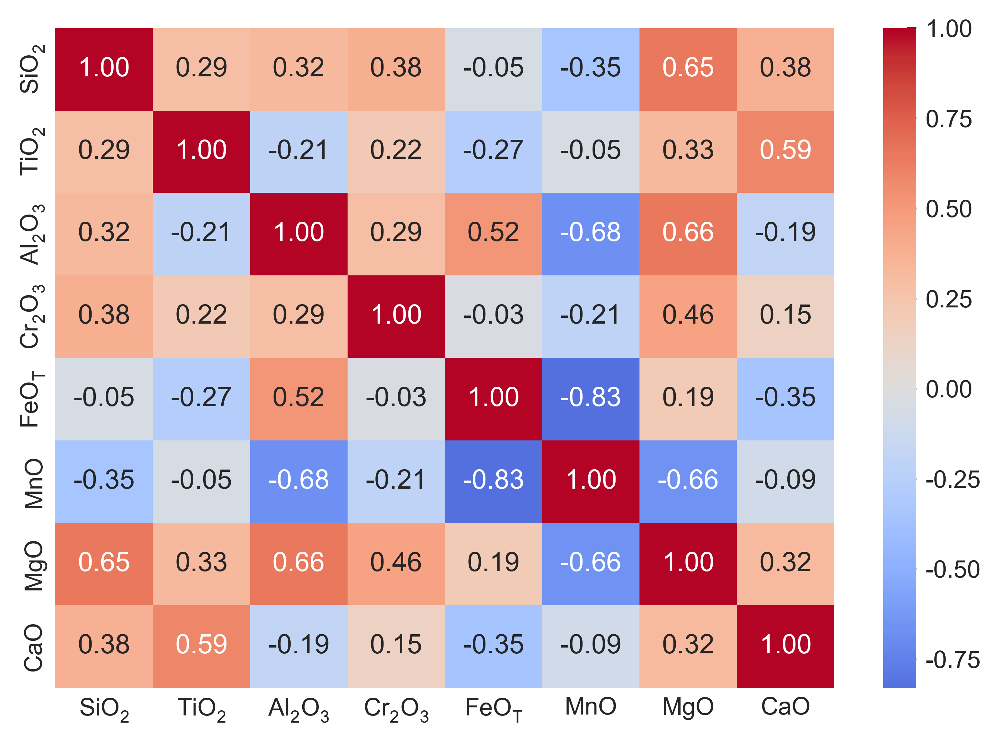

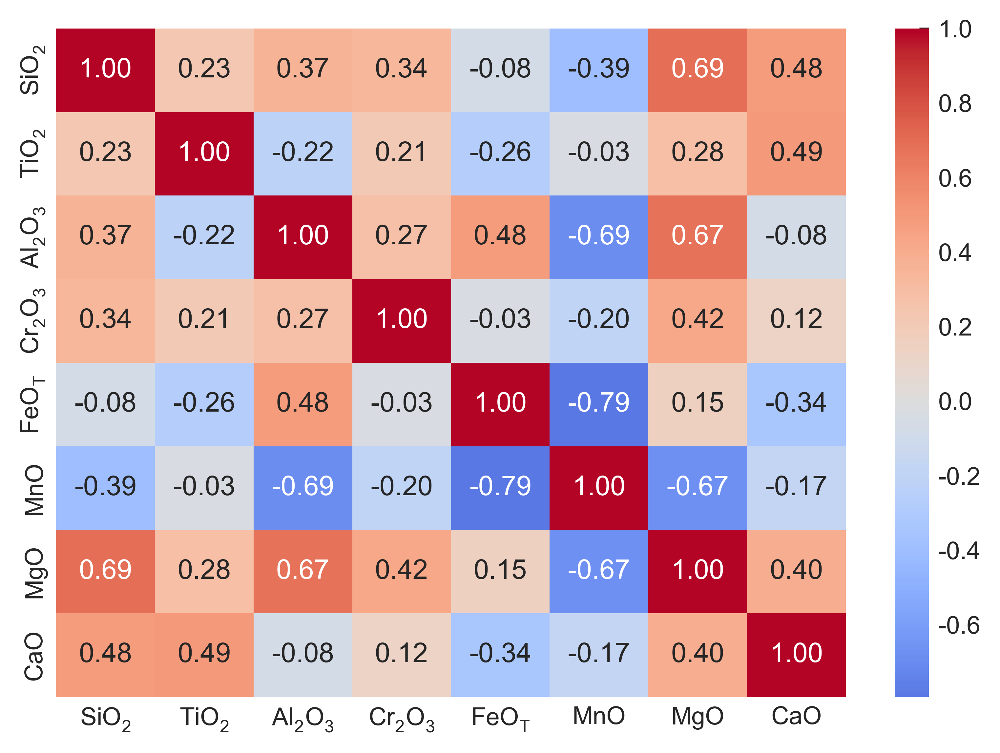

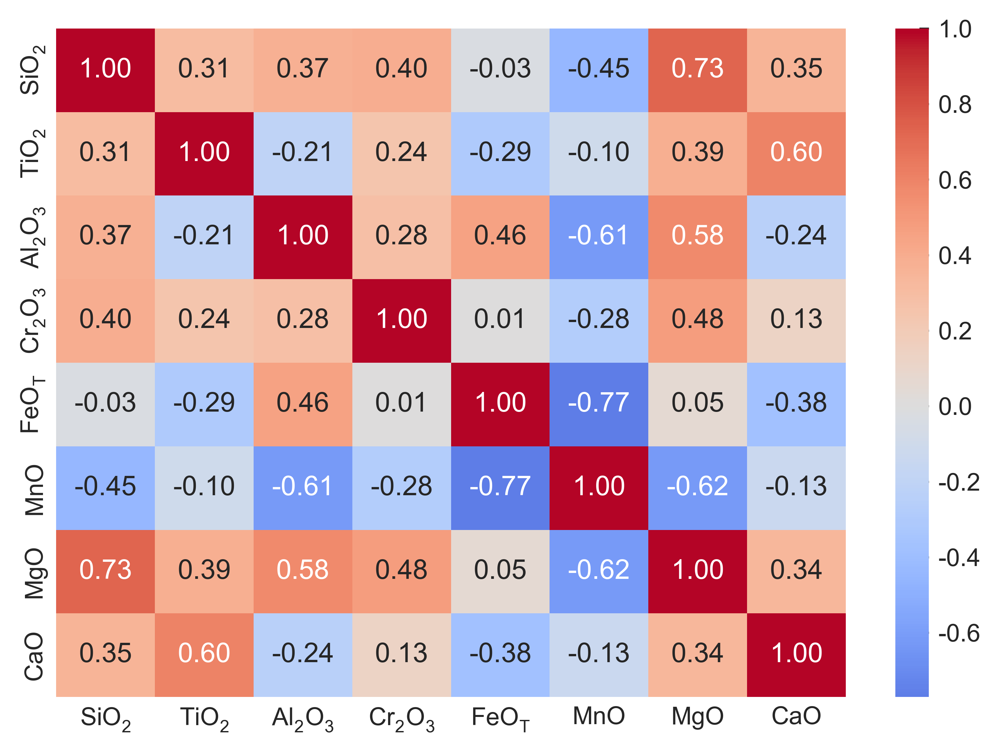

In [23]:
# Correlation Matrix
for i in range(3):
    df = major_dataset[major_dataset['Type']==label_names[i]].reset_index()
    index = df.index
    corr_matrix = np.corrcoef(scaler.fit_transform(X)[index].T)

    # plt.figure(figsize=(width, width*0.8), dpi=900)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',center=0,xticklabels=feature_names,yticklabels=feature_names)
    plt.tight_layout()
    # plt.savefig('Major PearsonCorrelation %s.svg'%label_names[i])
    plt.show()

In [39]:
# SHAP Analysis
import shap
explainer = shap.TreeExplainer(grid3.best_estimator_)
shap_values = explainer.shap_values(X_train_scaled)
print(shap_values.shape)
print(explainer.expected_value)

(4236, 8, 3)
[0.13755551, 0.19632304, -0.2821413]


C:\Windows\Temp\ipykernel_6920\3410496746.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


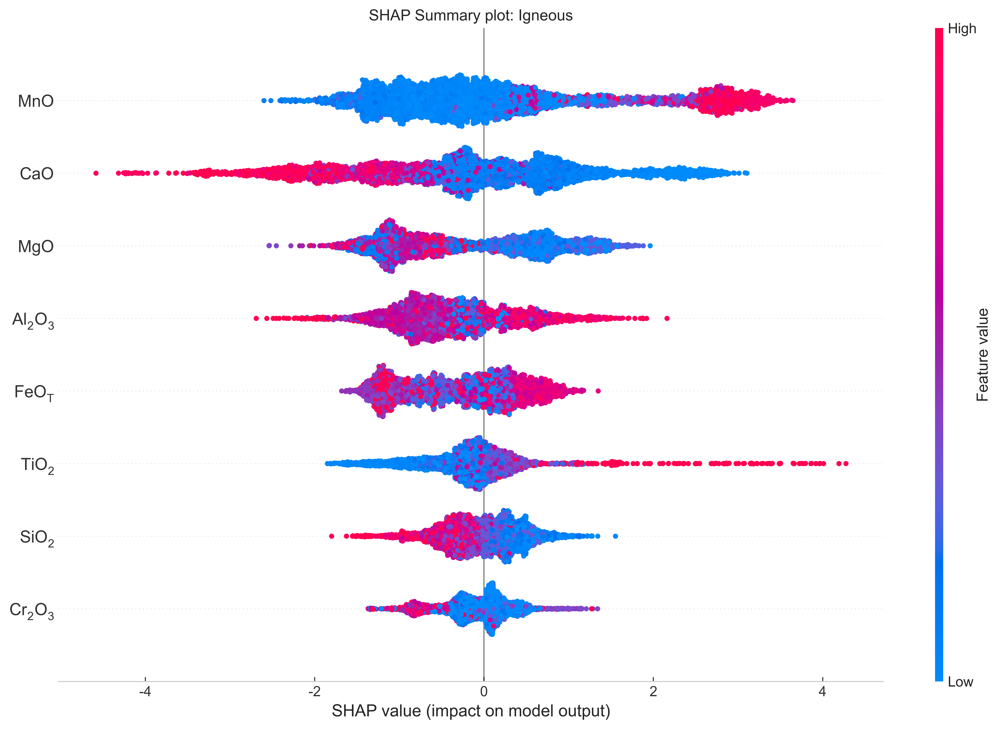

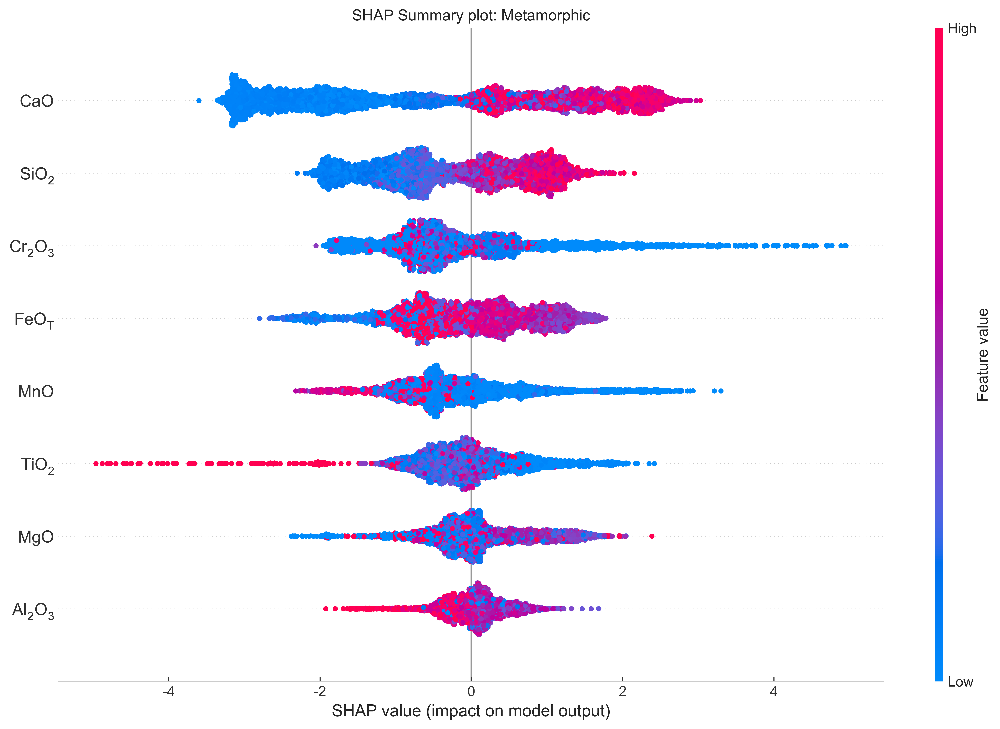

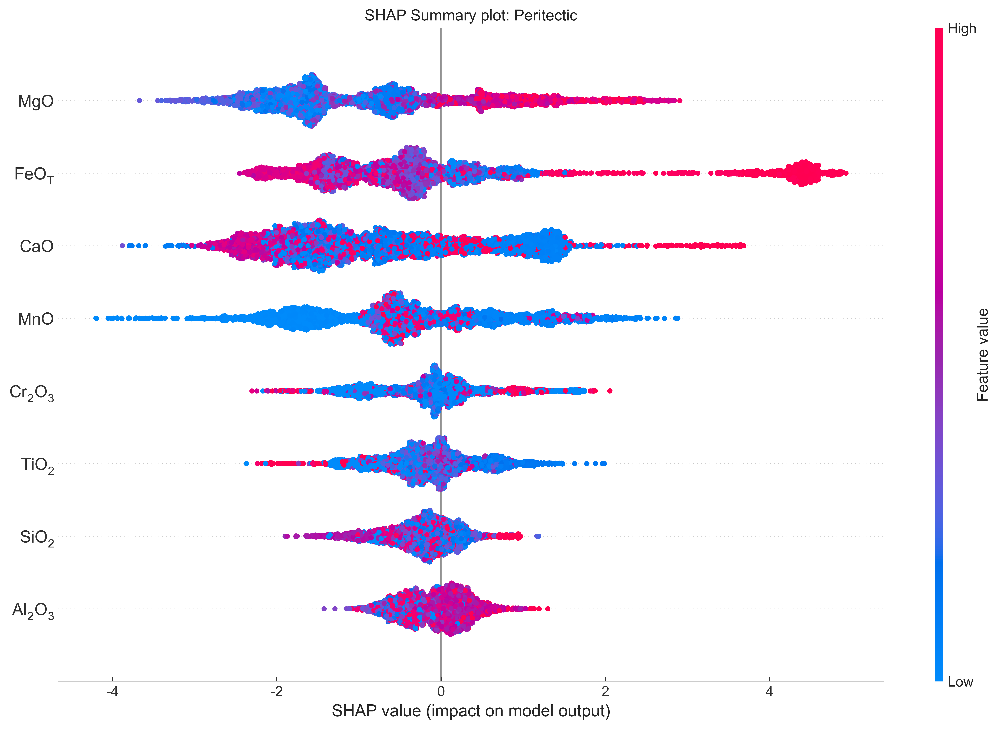

In [40]:
for i in range(3):
    # plt.figure(figsize=(width, width*0.618), dpi=900)
    plt.title('SHAP Summary plot: %s'%label_names[i]) # SHAP Summary Plot 
    shap.summary_plot(shap_values[:,:,i],X_train_scaled,feature_names=feature_names,plot_type='dot',plot_size=(12, 8),show=False)
    plt.tight_layout()
    # plt.savefig('SHAP Major %s.svg'%label_names[i])
    plt.show()

In [38]:
# save models
import pickle
with open('Scaler_major_model.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    
with open('XGBoost_major_model.pkl', 'wb') as f:
    pickle.dump(grid3.best_estimator_, f)